In [7]:
from datasets import load_dataset

ds = load_dataset("hugginglearners/netflix-shows")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [9]:
df = ds["train"].to_pandas()


In [10]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

In [11]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,None,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,None,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",None,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,None,None,None,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,None,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",None,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",None,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0


#Count by Type (Movie vs TV Show)

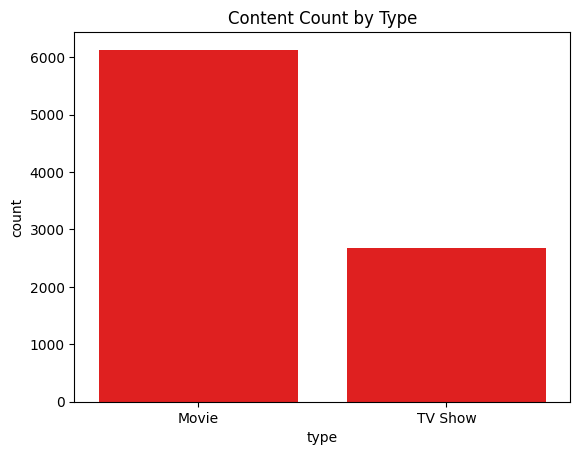

In [14]:

plt.figure()
sns.countplot(x='type', data=df, color='red')
plt.title("Content Count by Type")
plt.show()

#Content Growth Over Time

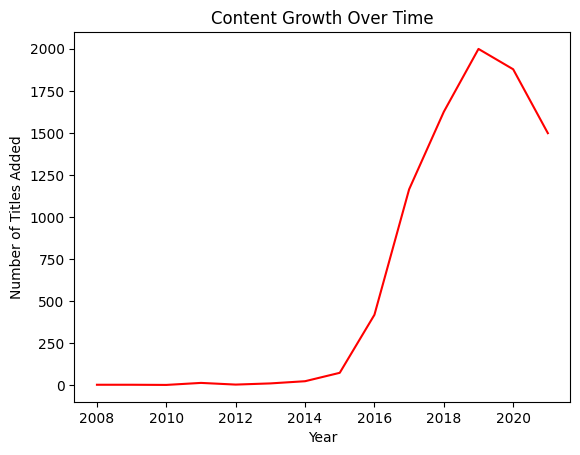

In [18]:
year_trend = df['year_added'].value_counts().sort_index()

plt.figure()
year_trend.plot( color='red')
plt.title("Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

#Top Genres according to genres

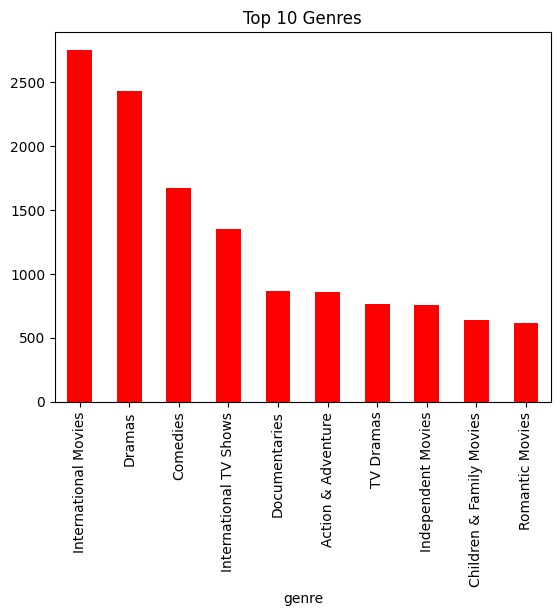

In [19]:
df['listed_in'] = df['listed_in'].fillna('')
df_genre = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')

top_genres = df_genre['genre'].value_counts().head(10)

plt.figure()
top_genres.plot(kind='bar', color='red')
plt.title("Top 10 Genres")
plt.show()

Runtime Distribution

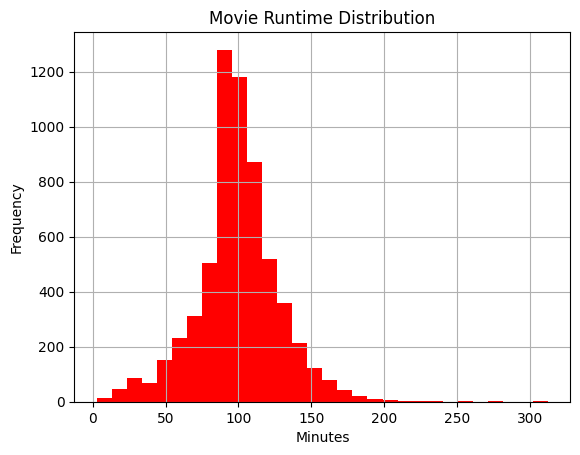

In [26]:
df_movies = df[df['type'] == 'Movie'].copy()

df_movies['duration'] = df_movies['duration'].str.replace(' min', '', regex=False)
df_movies['duration'] = pd.to_numeric(df_movies['duration'], errors='coerce')

plt.figure()
df_movies['duration'].dropna().hist(bins=30, color='red')

plt.title("Movie Runtime Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

#Top 10 Years with Most Content added

In [27]:
top_years = df['year_added'].value_counts().head(10)
print(top_years)

year_added
2019.0    1999
2020.0    1878
2018.0    1625
2021.0    1498
2017.0    1164
2016.0     418
2015.0      73
2014.0      23
2011.0      13
2013.0      10
Name: count, dtype: int64


In [ ]:
plt.savefig("netflix_growth.png")

summary = f"""
Total Titles: {len(df)}
Movies: {len(df[df['type']=='Movie'])}
TV Shows: {len(df[df['type']=='TV Show'])}

Top Genre: {top_genres.index[0]}
Year with Most Additions: {top_years.index[0]}
"""

with open("summary_report.txt", "w") as f:
    f.write(summary)

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 73.5 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1


In [ ]:
%%writefile app.py
import streamlit as st
st.title("Netflix Mini Dashboard")
st.write("Streamlit is working!")

Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦your url is: https://smooth-badgers-glow.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.195.24:8501

2026-02-24 11:13:17.038 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-02-24 11:13:17.119 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-02-24 11:13:17.171 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-02-24 11:13:17.185 Ple